# Federated Learning para Estimativa de SOC em Baterias de Íon-Lítio
## Comparação: FedAvg vs FedProx vs FedMA

**Autores:** Camila Vieira de Oliveira, Guilherme Tuchanski Rocha, Luiz Henrique Matoso

**Referências:**
- McMahan et al. (2017) — FedAvg
- Li et al. (2020) — FedProx
- Wang et al. (2020) — FedMA
- Lai et al. (2024) — FedCBE

**Dataset:** c — Samsung NMC + Wanxiang LFP

In [ ]:
!pip install -q torch numpy pandas matplotlib scikit-learn scipy openpyxl xlrd

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import linear_sum_assignment
import copy, os, zipfile, re, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cpu


---
# 1. Carregamento dos Dados CALCE

Faça upload dos ZIPs do CALCE (LFP e NMC).

In [ ]:
# Funções auxiliares para detectar metadata do nome do arquivo

def detect_temperature(path):
    """Detecta temperatura ambiente a partir do path."""
    # Padrão: '25C', '0C', '45C', '-10C', 'n10C'
    m = re.search(r'[-_/\\](-?\d+)\s*[cC](?![a-zA-Z])', path)
    if m:
        return int(m.group(1))
    m = re.search(r'[nN](\d+)[cC]', path)
    if m:
        return -int(m.group(1))
    # Procurar no nome da pasta pai
    parent = os.path.basename(os.path.dirname(path))
    for t in [50, 45, 40, 30, 25, 20, 15, 10, 0]:
        if str(t) in parent:
            return t
    return 25  # default


def detect_cycle(path):
    """Detecta tipo de ciclo de teste."""
    p = path.upper()
    for c in ['FUDS', 'US06', 'BJDST', 'DST']:
        if c in p:
            return c
    return 'UNK'


print('Funções auxiliares definidas.')

Funções auxiliares definidas.


## 1.1 Upload LFP

In [ ]:
from google.colab import files
print('Upload do(s) ZIP(s) LFP:')
uploaded_lfp = files.upload()

Upload do(s) ZIP(s) LFP:


Saving A123_DST-US06-FUDS-0.zip to A123_DST-US06-FUDS-0.zip
Saving A123_DST-US06-FUDS-10.zip to A123_DST-US06-FUDS-10.zip
Saving A123_DST-US06-FUDS-20.zip to A123_DST-US06-FUDS-20.zip
Saving A123_DST-US06-FUDS-25.zip to A123_DST-US06-FUDS-25.zip
Saving A123_DST-US06-FUDS-30.zip to A123_DST-US06-FUDS-30.zip
Saving A123_DST-US06-FUDS-40.zip to A123_DST-US06-FUDS-40.zip
Saving A123_DST-US06-FUDS-50.zip to A123_DST-US06-FUDS-50.zip
Saving A123_DST-US06-FUDS-N10.zip to A123_DST-US06-FUDS-N10.zip


In [ ]:
os.makedirs('data/lfp', exist_ok=True)
for zname in uploaded_lfp:
    if zname.endswith('.zip'):
        with zipfile.ZipFile(zname, 'r') as z:
            z.extractall('data/lfp')
        print(f'Extraído: {zname}')

lfp_files = []
for root, _, fnames in os.walk('data/lfp'):
    for f in fnames:
        if (f.endswith('.xlsx') or f.endswith('.xls')) and not f.startswith('~$'):
            lfp_files.append(os.path.join(root, f))

print(f'Arquivos LFP: {len(lfp_files)}')
for f in lfp_files:
    print(f'  {f}')

Extraído: A123_DST-US06-FUDS-0.zip
Extraído: A123_DST-US06-FUDS-10.zip
Extraído: A123_DST-US06-FUDS-20.zip
Extraído: A123_DST-US06-FUDS-25.zip
Extraído: A123_DST-US06-FUDS-30.zip
Extraído: A123_DST-US06-FUDS-40.zip
Extraído: A123_DST-US06-FUDS-50.zip
Extraído: A123_DST-US06-FUDS-N10.zip
Arquivos LFP: 20
  data/lfp/DST-US06-FUDS-25/A1-008-DST-US06-FUDS-25-20120827.xlsx
  data/lfp/DST-US06-FUDS-25/A1-007-DST-US06-FUDS-25-20120827.xlsx
  data/lfp/DST-US06-FUDS-N10/A1-007-DST-US06-FUDS-N10-20120829.xlsx
  data/lfp/DST-US06-FUDS-N10/A1-008-DST-US06-FUDS-N10-20120829.xlsx
  data/lfp/DST-US06-FUDS-50/A1-008-DST-US06-FUDS-50-20120824.xlsx
  data/lfp/DST-US06-FUDS-50/A1-007-DST-US06-FUDS-50-20120824.xlsx
  data/lfp/DST-US06-FUDS-10/A1-008-DST-US06-FUDS-10-20120815.xlsx
  data/lfp/DST-US06-FUDS-10/A1-007-DST-US06-FUDS-10-20120815.xlsx
  data/lfp/DST-US06-FUDS-40/A1-007-DST-US06-FUDS-40-20120822.xlsx
  data/lfp/DST-US06-FUDS-40/A1-008-DST-US06-FUDS-40-20120822.xlsx
  data/lfp/DST-US06-FUDS-30/A1-

In [ ]:
def load_battery_file(fpath, chemistry):
    """
    Carrega um arquivo de bateria CALCE e retorna DataFrame padronizado.
    Funciona para LFP (.xlsx Sheet1) e NMC (.xls com Channel sheet).
    """
    try:
        xls = pd.ExcelFile(fpath)
        # Tentar sheet com 'Channel' (NMC), senão pegar a primeira
        ch_sheets = [s for s in xls.sheet_names if 'channel' in s.lower()]
        sheet = ch_sheets[0] if ch_sheets else xls.sheet_names[0]
        df = pd.read_excel(fpath, sheet_name=sheet)
    except Exception as e:
        print(f'  ERRO {os.path.basename(fpath)}: {e}')
        return None

    # Mapear colunas de forma flexível
    cols = {c.strip().lower(): c for c in df.columns}
    found = {}
    for target, patterns in {
        'current':     ['current(a)', 'current', 'i(a)', 'i (a)'],
        'voltage':     ['voltage(v)', 'voltage', 'v(v)', 'ecell/v', 'ecell'],
        'temperature': ['temperature', 'temp', 'surface temperature', 'temperature(c)'],
    }.items():
        for p in patterns:
            if p in cols:
                found[target] = cols[p]
                break

    if 'current' not in found or 'voltage' not in found:
        print(f'  SKIP {os.path.basename(fpath)}: colunas não encontradas. Disponíveis: {list(df.columns)}')
        return None

    out = pd.DataFrame()
    out['voltage'] = pd.to_numeric(df[found['voltage']], errors='coerce')
    out['current'] = pd.to_numeric(df[found['current']], errors='coerce')
    out['temperature'] = pd.to_numeric(df[found.get('temperature', '')], errors='coerce') if 'temperature' in found else float(detect_temperature(fpath))
    out = out.dropna().reset_index(drop=True)

    if len(out) < 200:
        print(f'  SKIP {os.path.basename(fpath)}: {len(out)} amostras (mín 200)')
        return None

    # SOC via Coulomb counting normalizado para [0, 1]
    q = out['current'].cumsum()
    q_shifted = q - q.min()
    q_range = q_shifted.max()
    if q_range == 0:
        print(f'  SKIP {os.path.basename(fpath)}: corrente constante')
        return None
    out['soc'] = q_shifted / q_range

    temp = detect_temperature(fpath)
    cycle = detect_cycle(fpath)
    cid = f'{chemistry}_{temp}C_{cycle}'

    print(f'  OK: {cid:25s} | {len(out):>7,} amostras')
    return {'client_id': cid, 'chemistry': chemistry, 'temperature': temp,
            'cycle': cycle, 'data': out}


# Processar LFP
lfp_datasets = []
for f in lfp_files:
    result = load_battery_file(f, 'LFP')
    if result:
        lfp_datasets.append(result)

print(f'\nDatasets LFP: {len(lfp_datasets)}')

  OK: LFP_25C_FUDS              |  25,106 amostras
  OK: LFP_25C_FUDS              |  24,469 amostras
  OK: LFP_10C_FUDS              |  19,784 amostras
  OK: LFP_10C_FUDS              |  13,203 amostras
  OK: LFP_50C_FUDS              |  25,342 amostras
  OK: LFP_50C_FUDS              |  24,763 amostras
  OK: LFP_10C_FUDS              |  24,166 amostras
  OK: LFP_10C_FUDS              |  23,881 amostras
  OK: LFP_40C_FUDS              |  24,766 amostras
  OK: LFP_40C_FUDS              |  25,414 amostras
  OK: LFP_30C_FUDS              |  25,094 amostras
  OK: LFP_30C_FUDS              |  24,598 amostras
  OK: LFP_0C_FUDS               |  23,248 amostras
  OK: LFP_0C_FUDS               |  23,098 amostras
  OK: LFP_20C_FUDS              |  24,304 amostras
  OK: LFP_20C_FUDS              |  24,992 amostras
  OK: LFP_20C_FUDS              |  26,099 amostras
  OK: LFP_20C_FUDS              |  24,992 amostras
  OK: LFP_20C_FUDS              |  25,589 amostras
  OK: LFP_20C_FUDS             

## 1.2 Upload NMC

In [ ]:
print('Upload do(s) ZIP(s) NMC:')
uploaded_nmc = files.upload()

Upload do(s) ZIP(s) NMC:


Saving SP2_0C_BJDST.zip to SP2_0C_BJDST.zip
Saving SP2_0C_DST.zip to SP2_0C_DST.zip
Saving SP2_0C_FUDS.zip to SP2_0C_FUDS.zip
Saving SP2_0C_US06.zip to SP2_0C_US06.zip
Saving SP2_25C_BJDST.zip to SP2_25C_BJDST.zip
Saving SP2_25C_DST.zip to SP2_25C_DST.zip
Saving SP2_25C_FUDS.zip to SP2_25C_FUDS.zip
Saving SP2_25C_US06.zip to SP2_25C_US06.zip
Saving SP2_45C_BJDST.zip to SP2_45C_BJDST.zip
Saving SP2_45C_DST.zip to SP2_45C_DST.zip
Saving SP2_45C_FUDS.zip to SP2_45C_FUDS.zip
Saving SP2_45C_US06.zip to SP2_45C_US06.zip


In [ ]:
os.makedirs('data/nmc', exist_ok=True)
for zname in uploaded_nmc:
    if zname.endswith('.zip'):
        with zipfile.ZipFile(zname, 'r') as z:
            z.extractall('data/nmc')
        print(f'Extraído: {zname}')

nmc_files = []
for root, _, fnames in os.walk('data/nmc'):
    for f in fnames:
        if (f.endswith('.xls') or f.endswith('.xlsx')) and not f.startswith('~$'):
            nmc_files.append(os.path.join(root, f))

print(f'Arquivos NMC: {len(nmc_files)}')
for f in nmc_files:
    print(f'  {f}')

Extraído: SP2_0C_BJDST.zip
Extraído: SP2_0C_DST.zip
Extraído: SP2_0C_FUDS.zip
Extraído: SP2_0C_US06.zip
Extraído: SP2_25C_BJDST.zip
Extraído: SP2_25C_DST.zip
Extraído: SP2_25C_FUDS.zip
Extraído: SP2_25C_US06.zip
Extraído: SP2_45C_BJDST.zip
Extraído: SP2_45C_DST.zip
Extraído: SP2_45C_FUDS.zip
Extraído: SP2_45C_US06.zip
Arquivos NMC: 24
  data/nmc/11_11_2015_SP20-2_US06_80SOC.xls
  data/nmc/11_06_2015_SP20-2_FUDS_80SOC.xls
  data/nmc/12_17_2015_SP20-2_45C_BJDST_50SOC.xls
  data/nmc/02_26_2016_SP20-2_0C_US06_50SOC.xls
  data/nmc/12_16_2015_SP20-2_45C_US06_80SOC.xls
  data/nmc/12_17_2015_SP20-2_45C_BJDST_80SOC.xls
  data/nmc/11_09_2015_SP20-2_FUDS_50SOC.xls
  data/nmc/12_15_2015_SP20-2_45C_FUDS_50SOC.xls
  data/nmc/12_15_2015_SP20-2_45C_FUDS_80SOC.xls
  data/nmc/02_26_2016_SP20-2_0C_US06_80SOC.xls
  data/nmc/12_16_2015_SP20-2_45C_US06_50SOC.xls
  data/nmc/02_29_2016_SP20-2_0C_BJDST_50SOC.xls
  data/nmc/02_25_2016_SP20-2_0C_FUDS_50SOC.xls
  data/nmc/11_13_2015_SP20-2_BJDST_50SOC.xls
  data/

In [ ]:
nmc_datasets = []
for f in nmc_files:
    result = load_battery_file(f, 'NMC')
    if result:
        nmc_datasets.append(result)

print(f'\nDatasets NMC: {len(nmc_datasets)}')

  OK: NMC_25C_US06              |  11,898 amostras
  OK: NMC_25C_FUDS              |  13,681 amostras
  OK: NMC_45C_BJDST             |  15,840 amostras
  OK: NMC_0C_US06               |   8,056 amostras
  OK: NMC_45C_US06              |  12,786 amostras
  OK: NMC_45C_BJDST             |  19,694 amostras
  OK: NMC_25C_FUDS              |   9,308 amostras
  OK: NMC_45C_FUDS              |   9,593 amostras
  OK: NMC_45C_FUDS              |  13,520 amostras
  OK: NMC_0C_US06               |  11,445 amostras
  OK: NMC_45C_US06              |   9,105 amostras
  OK: NMC_0C_BJDST              |  14,564 amostras
  OK: NMC_0C_FUDS               |   9,057 amostras
  OK: NMC_25C_BJDST             |   8,385 amostras
  OK: NMC_0C_DST                |   8,084 amostras
  OK: NMC_45C_DST               |   9,089 amostras
  OK: NMC_0C_FUDS               |  11,614 amostras
  OK: NMC_45C_DST               |  13,621 amostras
  OK: NMC_25C_DST               |  12,561 amostras
  OK: NMC_0C_DST               

## 1.3 Consolidar clientes e criar DataLoaders

In [ ]:
# Juntar e mesclar duplicatas
all_ds = lfp_datasets + nmc_datasets
merged = {}
for ds in all_ds:
    cid = ds['client_id']
    if cid in merged:
        merged[cid]['data'] = pd.concat([merged[cid]['data'], ds['data']], ignore_index=True)
    else:
        merged[cid] = ds

all_ds = list(merged.values())

# Filtrar clientes com poucos dados
MIN_SAMPLES = 500
all_ds = [d for d in all_ds if len(d['data']) >= MIN_SAMPLES]

print(f'Clientes FL candidatos: {len(all_ds)}')
for d in all_ds:
    print(f"  {d['client_id']:25s} | {len(d['data']):>7,} amostras")

Clientes FL candidatos: 19
  LFP_25C_FUDS              |  24,669 amostras
  LFP_10C_FUDS              |  61,450 amostras
  LFP_50C_FUDS              |  24,963 amostras
  LFP_40C_FUDS              |  25,614 amostras
  LFP_30C_FUDS              |  24,798 amostras
  LFP_0C_FUDS               |  23,298 amostras
  LFP_20C_FUDS              | 126,176 amostras
  NMC_25C_US06              |  20,219 amostras
  NMC_25C_FUDS              |  22,989 amostras
  NMC_45C_BJDST             |  35,534 amostras
  NMC_0C_US06               |  19,501 amostras
  NMC_45C_US06              |  21,891 amostras
  NMC_45C_FUDS              |  23,113 amostras
  NMC_0C_BJDST              |  33,077 amostras
  NMC_0C_FUDS               |  20,671 amostras
  NMC_25C_BJDST             |  20,822 amostras
  NMC_0C_DST                |  18,395 amostras
  NMC_45C_DST               |  22,710 amostras
  NMC_25C_DST               |  22,062 amostras


Os clientes tem quantidades de amostras desbalanceadas. Isso afeta o experimento de duas formas:

- No **FedAvg/FedProx**: a agregação é ponderada por n_train, então o cliente com 150k vai ter ~8x mais influência no modelo global que o cliente com 18k. **O modelo global vai ser enviesado** para o perfil desse cliente.
- **No treino local**: o cliente com mais dados treina com mais batches por época, o que significa que **os pesos se afastam mais do modelo global a cada round** — aumentando a divergência.

Por esse motivo, escolhemos subsamplear os clientes grandes para que todos tenham tamanho similar. Ou seja, vamos, limitar a 20k amostras por cliente. Isso é o mais simples e o mais justo para a comparação.

In [ ]:
MAX_SAMPLES = 20000
for ds in all_ds:
    if len(ds['data']) > MAX_SAMPLES:
        ds['data'] = ds['data'].sample(n=MAX_SAMPLES, random_state=42).sort_index().reset_index(drop=True)
print(f'Clientes FL finais: {len(all_ds)}')
for d in all_ds:
    print(f"  {d['client_id']:25s} | {len(d['data']):>7,} amostras")

Clientes FL finais: 19
  LFP_25C_FUDS              |  20,000 amostras
  LFP_10C_FUDS              |  20,000 amostras
  LFP_50C_FUDS              |  20,000 amostras
  LFP_40C_FUDS              |  20,000 amostras
  LFP_30C_FUDS              |  20,000 amostras
  LFP_0C_FUDS               |  20,000 amostras
  LFP_20C_FUDS              |  20,000 amostras
  NMC_25C_US06              |  20,000 amostras
  NMC_25C_FUDS              |  20,000 amostras
  NMC_45C_BJDST             |  20,000 amostras
  NMC_0C_US06               |  19,501 amostras
  NMC_45C_US06              |  20,000 amostras
  NMC_45C_FUDS              |  20,000 amostras
  NMC_0C_BJDST              |  20,000 amostras
  NMC_0C_FUDS               |  20,000 amostras
  NMC_25C_BJDST             |  20,000 amostras
  NMC_0C_DST                |  18,395 amostras
  NMC_45C_DST               |  20,000 amostras
  NMC_25C_DST               |  20,000 amostras


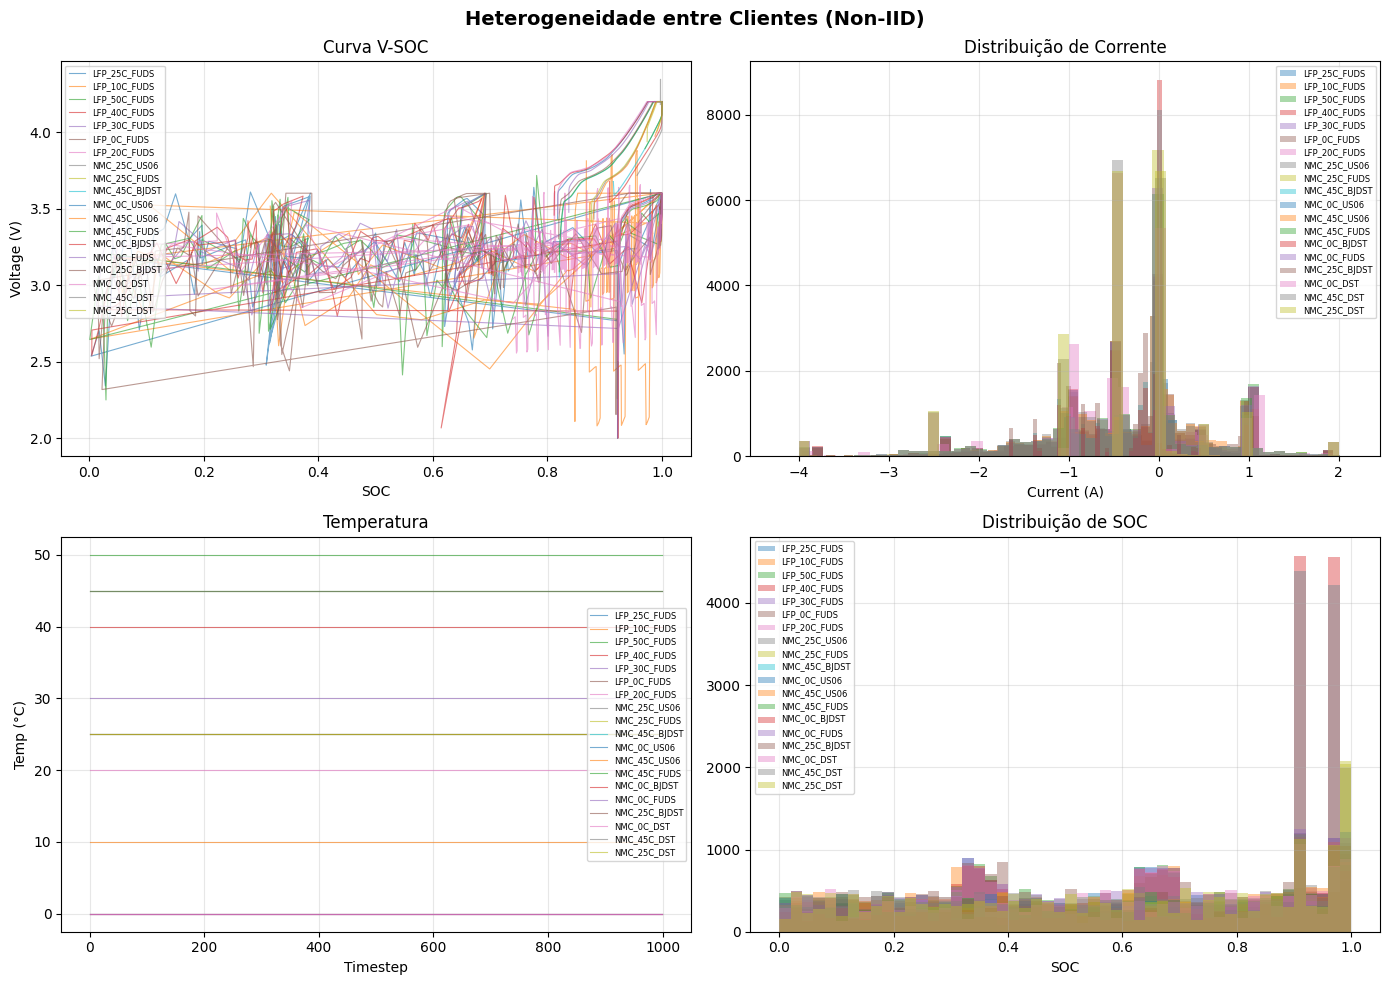

In [ ]:
# Visualizar heterogeneidade
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ds in all_ds:
    df, lbl = ds['data'], ds['client_id']
    n = min(len(df), 1000)
    axes[0,0].plot(df['soc'].values[:n], df['voltage'].values[:n], alpha=0.6, lw=0.8, label=lbl)
    axes[0,1].hist(df['current'].values, bins=50, alpha=0.4, label=lbl)
    axes[1,0].plot(df['temperature'].values[:n], alpha=0.6, lw=0.8, label=lbl)
    axes[1,1].hist(df['soc'].values, bins=50, alpha=0.4, label=lbl)

axes[0,0].set(xlabel='SOC', ylabel='Voltage (V)', title='Curva V-SOC')
axes[0,1].set(xlabel='Current (A)', title='Distribuição de Corrente')
axes[1,0].set(xlabel='Timestep', ylabel='Temp (°C)', title='Temperatura')
axes[1,1].set(xlabel='SOC', title='Distribuição de SOC')
for ax in axes.flat: ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('Heterogeneidade entre Clientes (Non-IID)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
class BatterySeqDataset(Dataset):
    """Janelas (V, I, T) -> SOC. Normalizado por cliente."""
    def __init__(self, V, I, T, S, seq_len=30):
        X = np.column_stack([V, I, T]).astype(np.float32)
        y = S.astype(np.float32)
        self.scaler_X = MinMaxScaler().fit(X)
        self.scaler_y = MinMaxScaler().fit(y.reshape(-1,1))
        self.X = self.scaler_X.transform(X)
        self.y = self.scaler_y.transform(y.reshape(-1,1)).flatten()
        self.seq_len = seq_len

    def __len__(self): return max(0, len(self.X) - self.seq_len)

    def __getitem__(self, i):
        return (torch.from_numpy(self.X[i:i+self.seq_len]),
                torch.tensor([self.y[i+self.seq_len]]))


SEQ_LEN = 30
BATCH_SIZE = 64
client_loaders = {}

for ds in all_ds:
    df = ds['data']
    n = len(df)
    t1, t2 = int(n*0.7), int(n*0.85)
    V, I, T, S = df['voltage'].values, df['current'].values, df['temperature'].values, df['soc'].values

    train_ds = BatterySeqDataset(V[:t1], I[:t1], T[:t1], S[:t1], SEQ_LEN)
    val_ds   = BatterySeqDataset(V[t1:t2], I[t1:t2], T[t1:t2], S[t1:t2], SEQ_LEN)
    test_ds  = BatterySeqDataset(V[t2:], I[t2:], T[t2:], S[t2:], SEQ_LEN)

    if len(train_ds) < 10 or len(test_ds) < 10:
        print(f'  SKIP {ds["client_id"]}: insuficiente após windowing')
        continue

    client_loaders[ds['client_id']] = {
        'train': DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
        'val':   DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False),
        'test':  DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False),
        'n_train': len(train_ds),
        'chemistry': ds['chemistry'], 'temperature': ds['temperature'], 'cycle': ds['cycle'],
    }
    print(f"{ds['client_id']:25s} | train={len(train_ds):>5} | val={len(val_ds):>5} | test={len(test_ds):>5}")

print(f'\nClientes prontos: {len(client_loaders)}')

LFP_25C_FUDS              | train=13970 | val= 2970 | test= 2970
LFP_10C_FUDS              | train=13970 | val= 2970 | test= 2970
LFP_50C_FUDS              | train=13970 | val= 2970 | test= 2970
LFP_40C_FUDS              | train=13970 | val= 2970 | test= 2970
LFP_30C_FUDS              | train=13970 | val= 2970 | test= 2970
LFP_0C_FUDS               | train=13970 | val= 2970 | test= 2970
LFP_20C_FUDS              | train=13970 | val= 2970 | test= 2970
NMC_25C_US06              | train=13970 | val= 2970 | test= 2970
NMC_25C_FUDS              | train=13970 | val= 2970 | test= 2970
NMC_45C_BJDST             | train=13970 | val= 2970 | test= 2970
NMC_0C_US06               | train=13620 | val= 2895 | test= 2896
NMC_45C_US06              | train=13970 | val= 2970 | test= 2970
NMC_45C_FUDS              | train=13970 | val= 2970 | test= 2970
NMC_0C_BJDST              | train=13970 | val= 2970 | test= 2970
NMC_0C_FUDS               | train=13970 | val= 2970 | test= 2970
NMC_25C_BJDST            

---
# 2. Modelo LSTM

In [ ]:
class SOC_LSTM(nn.Module):
    """LSTM para SOC (Lai et al., 2024)."""
    def __init__(self, input_size=3, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

HIDDEN = 32
m = SOC_LSTM(hidden_size=HIDDEN).to(device)
print(f'Parâmetros: {sum(p.numel() for p in m.parameters()):,}')

Parâmetros: 4,769


---
# 3. Treino, Avaliação e Agregação

In [ ]:
def train_local(model, loader, epochs, lr=1e-3, proximal_mu=0.0, global_params=None):
    """Treino local. proximal_mu > 0 = FedProx (Li et al., 2020)."""
    model.train()
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    total_loss, nb = 0.0, 0
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            if proximal_mu > 0 and global_params is not None:
                prox = sum(((lp-gp)**2).sum() for lp, gp in zip(model.parameters(), global_params))
                loss = loss + (proximal_mu / 2.0) * prox
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total_loss += loss.item(); nb += 1
    return total_loss / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader):
    """Retorna RMSE, MAE, R²."""
    model.eval()
    ps, ts = [], []
    for xb, yb in loader:
        ps.append(model(xb.to(device)).cpu()); ts.append(yb)
    if not ps: return {'rmse': float('inf'), 'mae': float('inf'), 'r2': -1}
    p, t = torch.cat(ps).numpy().flatten(), torch.cat(ts).numpy().flatten()
    return {'rmse': float(np.sqrt(mean_squared_error(t,p))),
            'mae': float(mean_absolute_error(t,p)),
            'r2': float(r2_score(t,p)) if len(t)>1 else 0.0}

In [ ]:
# --- AGREGAÇÃO ---

def fedavg(states, weights):
    """FedAvg (McMahan et al., 2017)."""
    total = sum(weights)
    w = [c/total for c in weights]
    return {k: sum(wi * states[i][k].float() for i, wi in enumerate(w)) for k in states[0]}


def fedma(states, weights, hs):
    """
    FedMA simplificado (Wang et al., 2020).
    Alinha neurônios LSTM via Hungarian matching antes de agregar.
    """
    if len(states) <= 1: return fedavg(states, weights)
    ref = states[0]
    aligned = [ref]
    # Assinatura = forget gate do weight_hh
    ref_sig = ref['lstm.weight_hh_l0'][hs:2*hs, :]

    for i in range(1, len(states)):
        st = states[i]
        sig = st['lstm.weight_hh_l0'][hs:2*hs, :]
        # Similaridade cosseno -> Hungarian matching
        rn = ref_sig / (ref_sig.norm(dim=1, keepdim=True) + 1e-8)
        cn = sig / (sig.norm(dim=1, keepdim=True) + 1e-8)
        _, perm_idx = linear_sum_assignment(-(rn @ cn.t()).cpu().numpy())
        perm = torch.LongTensor(perm_idx)

        ns = copy.deepcopy(st)
        # Permutar gates (i,f,g,o) nas linhas de weight e bias
        for wk in ['lstm.weight_ih_l0', 'lstm.weight_hh_l0']:
            ns[wk] = torch.cat([ch[perm] for ch in ns[wk].chunk(4, 0)], 0)
        for bk in ['lstm.bias_ih_l0', 'lstm.bias_hh_l0']:
            ns[bk] = torch.cat([ch[perm] for ch in ns[bk].chunk(4, 0)], 0)
        # Permutar colunas da recorrência
        ns['lstm.weight_hh_l0'] = torch.cat([ch[:, perm] for ch in ns['lstm.weight_hh_l0'].chunk(4, 0)], 0)
        # Permutar entrada do fc
        ns['fc.weight'] = ns['fc.weight'][:, perm]
        aligned.append(ns)

    return fedavg(aligned, weights)

---
# 4. Loop FL

In [ ]:
def run_fl(strategy='fedavg', n_rounds=50, local_epochs=5,
           hidden_size=32, lr=1e-3, proximal_mu=0.01, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    print(f'\n{"="*55}')
    print(f'  {strategy.upper()} | rounds={n_rounds} | epochs={local_epochs}')
    print(f'{"="*55}')

    gm = SOC_LSTM(hidden_size=hidden_size).to(device)
    hist = {'round':[], 'rmse':[], 'mae':[], 'r2':[],
            'per_client': {c:[] for c in client_loaders}}

    for rnd in range(1, n_rounds+1):
        gs = copy.deepcopy(gm.state_dict())
        gp = [p.clone().detach() for p in gm.parameters()]
        ls, lw = [], []

        for cid, ldr in client_loaders.items():
            lm = SOC_LSTM(hidden_size=hidden_size).to(device)
            lm.load_state_dict(copy.deepcopy(gs))
            mu = proximal_mu if strategy=='fedprox' else 0.0
            g = gp if strategy=='fedprox' else None
            train_local(lm, ldr['train'], local_epochs, lr, mu, g)
            ls.append(copy.deepcopy(lm.state_dict()))
            lw.append(ldr['n_train'])

        ns = fedma(ls, lw, hidden_size) if strategy=='fedma' else fedavg(ls, lw)
        gm.load_state_dict(ns)

        rs, ms, r2s = [], [], []
        for cid, ldr in client_loaders.items():
            ev = evaluate(gm, ldr['test'])
            hist['per_client'][cid].append(ev['rmse'])
            rs.append(ev['rmse']); ms.append(ev['mae']); r2s.append(ev['r2'])

        hist['round'].append(rnd)
        hist['rmse'].append(np.mean(rs))
        hist['mae'].append(np.mean(ms))
        hist['r2'].append(np.mean(r2s))

        if rnd % 10 == 0 or rnd == 1:
            print(f'  R{rnd:3d}/{n_rounds} | RMSE={np.mean(rs):.4f} | MAE={np.mean(ms):.4f} | R²={np.mean(r2s):.4f}')

    print(f'  FINAL: RMSE={hist["rmse"][-1]:.4f} MAE={hist["mae"][-1]:.4f} R²={hist["r2"][-1]:.4f}')
    return hist

---
# 5. Executar Experimentos

In [ ]:
CFG = dict(n_rounds=50, local_epochs=5, hidden_size=HIDDEN, lr=1e-3, seed=42)

res_avg  = run_fl(strategy='fedavg',  **CFG)
res_prox = run_fl(strategy='fedprox', proximal_mu=0.01, **CFG)
res_ma   = run_fl(strategy='fedma',   **CFG)


  FEDAVG | rounds=50 | epochs=5
  R  1/50 | RMSE=0.2627 | MAE=0.2236 | R²=0.1542
  R 10/50 | RMSE=0.3498 | MAE=0.2949 | R²=-0.5499
  R 20/50 | RMSE=0.3549 | MAE=0.2986 | R²=-0.5930
  R 30/50 | RMSE=0.3415 | MAE=0.2828 | R²=-0.4611
  R 40/50 | RMSE=0.3537 | MAE=0.2939 | R²=-0.5687
  R 50/50 | RMSE=0.3460 | MAE=0.2861 | R²=-0.4998
  FINAL: RMSE=0.3460 MAE=0.2861 R²=-0.4998

  FEDPROX | rounds=50 | epochs=5
  R  1/50 | RMSE=0.3071 | MAE=0.2579 | R²=-0.1451
  R 10/50 | RMSE=0.3491 | MAE=0.2913 | R²=-0.5342
  R 20/50 | RMSE=0.3732 | MAE=0.3152 | R²=-0.7540
  R 30/50 | RMSE=0.3708 | MAE=0.3125 | R²=-0.7305
  R 40/50 | RMSE=0.3618 | MAE=0.3039 | R²=-0.6470
  R 50/50 | RMSE=0.3590 | MAE=0.3009 | R²=-0.6209
  FINAL: RMSE=0.3590 MAE=0.3009 R²=-0.6209

  FEDMA | rounds=50 | epochs=5
  R  1/50 | RMSE=0.2627 | MAE=0.2236 | R²=0.1542
  R 10/50 | RMSE=0.3505 | MAE=0.2943 | R²=-0.5551
  R 20/50 | RMSE=0.3559 | MAE=0.2973 | R²=-0.5990
  R 30/50 | RMSE=0.3399 | MAE=0.2774 | R²=-0.4479
  R 40/50 | RMSE=

---
# 6. Resultados

In [ ]:
# Convergência
plt.figure(figsize=(12,6))
plt.plot(res_avg['round'],  res_avg['rmse'],  'b-o', ms=3, lw=2, label='FedAvg')
plt.plot(res_prox['round'], res_prox['rmse'], 'r-s', ms=3, lw=2, label='FedProx')
plt.plot(res_ma['round'],   res_ma['rmse'],   'g-^', ms=3, lw=2, label='FedMA')
plt.xlabel('Round'); plt.ylabel('RMSE')
plt.title('Convergência: FedAvg vs FedProx vs FedMA', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# RMSE por cliente
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)
for idx, (nm, res) in enumerate([('FedAvg',res_avg),('FedProx',res_prox),('FedMA',res_ma)]):
    for cid, vals in res['per_client'].items():
        info = client_loaders[cid]
        axes[idx].plot(res['round'], vals, alpha=0.7, lw=0.9,
                       label=f"{info['chemistry']} {info['temperature']}°C")
    axes[idx].set_title(nm, fontweight='bold'); axes[idx].set_xlabel('Round')
    axes[idx].legend(fontsize=6); axes[idx].grid(alpha=0.3)
axes[0].set_ylabel('RMSE')
plt.suptitle('RMSE por Cliente', fontweight='bold'); plt.tight_layout(); plt.show()

In [ ]:
# Tabela comparativa
print('='*60)
print(f'{"Técnica":<12}{"RMSE":>10}{"MAE":>10}{"R²":>10}{"Conv":>10}')
print('-'*60)
for nm, r in [('FedAvg',res_avg),('FedProx',res_prox),('FedMA',res_ma)]:
    f = r['rmse'][-1]
    cv = next((rd for rd,v in zip(r['round'],r['rmse']) if v <= f*1.05), '—')
    print(f'{nm:<12}{f:>10.4f}{r["mae"][-1]:>10.4f}{r["r2"][-1]:>10.4f}{str(cv):>10}')
print('='*60)
print('Valores em escala [0,1]. ×100 para % SOC.')

---
# 7. Baseline Centralizado

In [ ]:
torch.manual_seed(42)
cm = SOC_LSTM(hidden_size=HIDDEN).to(device)

# Juntar todos os dados de treino
aX, aY = [], []
for ldr in client_loaders.values():
    for xb, yb in ldr['train']: aX.append(xb); aY.append(yb)
cds = torch.utils.data.TensorDataset(torch.cat(aX), torch.cat(aY))
cdl = DataLoader(cds, batch_size=BATCH_SIZE, shuffle=True)

opt = optim.Adam(cm.parameters(), lr=1e-3)
crit = nn.MSELoss()
for ep in range(CFG['n_rounds'] * CFG['local_epochs']):
    cm.train()
    for xb, yb in cdl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss = crit(cm(xb), yb); loss.backward()
        torch.nn.utils.clip_grad_norm_(cm.parameters(), 1.0); opt.step()
    if (ep+1) % 50 == 0: print(f'  Epoch {ep+1}')

print('\nBaseline centralizado:')
cr = []
for cid, ldr in client_loaders.items():
    ev = evaluate(cm, ldr['test'])
    cr.append(ev['rmse'])
    print(f'  {cid}: RMSE={ev["rmse"]:.4f}')

print(f'\n  Central:  RMSE={np.mean(cr):.4f}')
print(f'  FedAvg:   RMSE={res_avg["rmse"][-1]:.4f}')
print(f'  FedProx:  RMSE={res_prox["rmse"][-1]:.4f}')
print(f'  FedMA:    RMSE={res_ma["rmse"][-1]:.4f}')

---
# 8. Múltiplas Seeds

In [ ]:
SEEDS = [42, 123, 456]
multi = {s: [] for s in ['fedavg','fedprox','fedma']}
for sd in SEEDS:
    for st in ['fedavg','fedprox','fedma']:
        r = run_fl(strategy=st, n_rounds=30, local_epochs=5,
                   hidden_size=HIDDEN, lr=1e-3, proximal_mu=0.01, seed=sd)
        multi[st].append({'rmse':r['rmse'][-1],'mae':r['mae'][-1],'r2':r['r2'][-1]})

print('\n'+'='*60)
print(f'{"Técnica":<12}{"RMSE":>18}{"MAE":>18}{"R²":>18}')
print('-'*60)
for s in ['fedavg','fedprox','fedma']:
    rm=[x['rmse'] for x in multi[s]]
    ma=[x['mae'] for x in multi[s]]
    r2=[x['r2'] for x in multi[s]]
    print(f'{s.upper():<12}{np.mean(rm):.4f}±{np.std(rm):.4f}   '
          f'{np.mean(ma):.4f}±{np.std(ma):.4f}   '
          f'{np.mean(r2):.4f}±{np.std(r2):.4f}')
print('='*60)